# Retraining Cellpose on Custom Data

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/cellpose_retraining_colab.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_retraining_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [128]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "cellpose",
# ]
# ///

## Overview

In this section, we’ll walk through how to **retrain Cellpose on your own data**. This is useful when the default models don’t perform well on your specific cell type, staining method, or imaging modality.

Retraining allows Cellpose to learn directly from your examples—leading to better segmentation accuracy and more relevant masks for your experiments.

We’ll cover:
- Preparing your training data (images + label masks)
- Mounting your Google Drive to access files
- Setting training parameters
- Running the training process
- Evaluating the new model on test images


‼ MENTION NAPARI

> 💡 You’ll need pairs of raw microscopy images and their corresponding label masks. If you haven’t labeled your images yet, we recommend using the [Cellpose GUI](https://cellpose.readthedocs.io/en/latest/gui.html#training-your-own-cellpose-model) to draw or edit masks manually before starting.

The dataset we’ll use here can be downloaded below. It includes both training and test images:
<a href="../../../_static/data/05_segmentation_cellpose_training.zip" download>
<i class="fas fa-download"></i> Cellpose Training Dataset</a>

<p class="alert alert-warning">
    <strong>⚠️ Note:</strong> This notebook is designed to run in <a href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_retraining_notebook.ipynb" target="_blank"> Google Colab</a>. If you want to run it locally, you may need to adjust some paths and install the required packages.
</p>

## Import Libraries

In [129]:
from pathlib import Path

import matplotlib.pyplot as plt
from cellpose import core, io, metrics, models, train

## Setup

In [130]:
io.logger_setup()  # to get printing of progress

use_gpu = core.use_gpu()
print("GPU available:", use_gpu)

2026-06-08 14:02:30,155 [INFO] WRITING LOG OUTPUT TO /Users/fdrgsp/.cellpose/run.log
2026-06-08 14:02:30,157 [INFO] 
cellpose version: 	4.1.1 
platform:       	darwin 
python version: 	3.13.3 
torch version:  	2.12.0
2026-06-08 14:02:30,431 [INFO] ** TORCH MPS version installed and working. **
GPU available: True


## Data Handling

Cellpose expects images and their corresponding masks to live **in the same folder**, paired by a shared base name. Each image and mask share a numeric prefix — images have an `_img` suffix, masks have a `_labels` suffix.

Both the `train` and `test` folders follow the same layout:

```
cellpose_data/
├── train/
│   ├── 000_img.tif
│   ├── 000_labels.tif
│   ├── 001_img.tif
│   ├── 001_labels.tif
│   └── ...
└── test/
    ├── 008_img.tif
    ├── 008_labels.tif
    ├── 009_img.tif
    ├── 009_labels.tif
    └── ...
```

You'll also need to **split your data** into a `train` and a `test` folder. The model learns from the training set and is evaluated on the test set—images it has never seen during training.

> 💡 If you haven't labeled your images yet, the [Cellpose GUI](https://cellpose.readthedocs.io/en/latest/gui.html#training-your-own-cellpose-model) lets you draw or correct masks manually and saves them with the `_labels` suffix automatically.

The first step is to define the `train` and `test` directories, then load the data with [`io.load_train_test_data`](https://cellpose.readthedocs.io/en/latest/api.html#cellpose.io.load_train_test_data), passing both the image and mask suffixes so Cellpose can pair them correctly.

In [ ]:
# ROOT_FOLDER_PATH = Path("data/05_segmentation_cellpose_training")
ROOT_FOLDER_PATH = Path("/Users/fdrgsp/Desktop/05_segmentation_cellpose_training")

train_dir = ROOT_FOLDER_PATH / "train"
test_dir = ROOT_FOLDER_PATH / "test"

# add name filters to select only images and masks from the folders
# `mask_filter` identifies mask files by their suffix
# (e.g. "_seg.npy" for files like "img_000_seg.npy").
mask_filter = "_seg.npy"

# if necessary, you can also specify an `image_filter` to select images with a specific
# suffix (e.g. "_img" for files like "img_000_c1.tif").
# image_filter = "_c1"

# Load training and test data
output = io.load_train_test_data(
    str(train_dir),
    str(test_dir),
    mask_filter=mask_filter,
    # image_filter=image_filter
)

# assign the output to the appropriate variables
train_data, train_labels, _, test_data, test_labels, _ = output

2026-06-08 14:23:55,411 [INFO] not all flows are present, running flow generation for all images
2026-06-08 14:23:55,441 [INFO] 5 / 5 images in /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/train folder have labels
2026-06-08 14:23:55,443 [INFO] not all flows are present, running flow generation for all images
2026-06-08 14:23:55,461 [INFO] 3 / 3 images in /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/test folder have labels


During training, Cellpose will:
- Load batches of training images
- Compare its predictions to the ground-truth masks
- Adjust itself (via backpropagation) to reduce errors over time

### Init the Model

Before we can train a new model, we need to initialize Cellpose with the correct settings.

Here, we’ll:
- Specify the **model type** (e.g., "cpsam" (default), "cyto" or "nuclei") to use as a base model
- Set the **channels** depending on how your images are structured (e.g., single-channel grayscale, or dual-channel with nuclei and cytoplasm)
- Choose where to **save the model weights** during training

> 💡 Even when training a new model, Cellpose builds on a pre-trained backbone (unless you explicitly start from scratch). This helps it learn faster and perform better—especially on small datasets.


In [138]:
# Initialize the Cellpose model
model = models.CellposeModel(model_type="cpsam", gpu=use_gpu)

2026-06-08 14:24:02,765 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-06-08 14:24:02,779 [INFO] ** TORCH MPS version installed and working. **
2026-06-08 14:24:02,780 [INFO] >>>> using GPU (MPS)
2026-06-08 14:24:04,698 [INFO] >>>> loading model /Users/fdrgsp/.cellpose/models/cpsam


In [139]:
# run model on test images
masks, _, _ = model.eval(test_data, batch_size=32)

2026-06-08 14:24:09,693 [INFO] 100%|##########| 3/3 [00:04<00:00,  1.44s/it]


In [141]:
# check performance using ground truth labels
# average_precision returns AP at IoU thresholds [0.5, 0.75, 0.9] by default
values = metrics.average_precision(test_labels, masks)
average_precision, false_positives, false_negatives, _ = values

print(f"average precision at iou threshold 0.5  = {average_precision[:, 0].mean():.3f}")
print(f"average precision at iou threshold 0.75 = {average_precision[:, 1].mean():.3f}")
print(f"average precision at iou threshold 0.9  = {average_precision[:, 2].mean():.3f}")
print(f"average false positives per image = {false_positives.mean():.3f}")
print(f"average false negatives per image = {false_negatives.mean():.3f}")

average precision at iou threshold 0.5  = 0.735
average precision at iou threshold 0.75 = 0.166
average precision at iou threshold 0.9  = 0.001
average false positives per image = 67.444
average false negatives per image = 100.222


Let's now visualize the results for the test images.

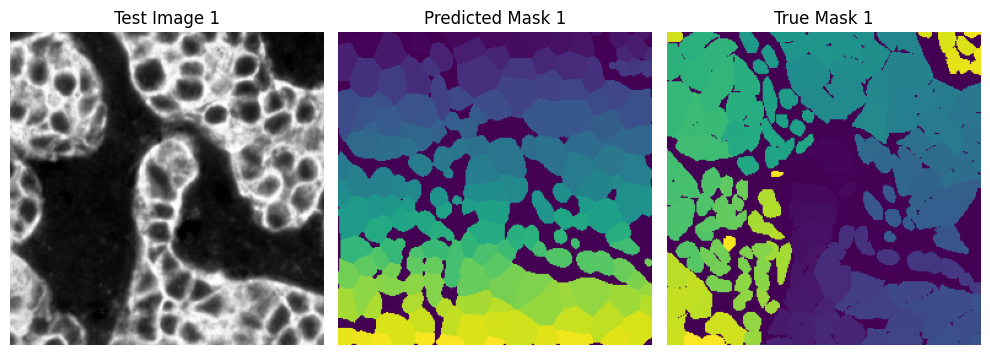

In [146]:
n = 1  # test image index to visualize
cyto_ch = 1  # channel index for cytoplasm (0=nucleus, 1=cytoplasm in this dataset)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(test_data[n][cyto_ch], cmap="gray")
plt.title(f"Test Image {n}")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(masks[n])
plt.title(f"Predicted Mask {n}")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(test_labels[n])
plt.title(f"True Mask {n}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Train New Model

Now we're ready to train! Before running, it's worth understanding what each training parameter controls:

- **Number of epochs** — one epoch = one full pass through all training images. More epochs give the model more time to learn, but too many can lead to *overfitting*: the model memorizes the training data and performs worse on new images. Watch the test loss — if it starts rising while the train loss keeps falling, you've trained too long.
  *Example: with 8 training images, 50–100 epochs is usually enough.*

- **Learning rate** — controls how large each weight update is. Too high → the model overshoots and training becomes unstable (loss oscillates). Too low → the model learns very slowly or gets stuck. For fine-tuning a pre-trained model like Cellpose, a small value is preferred to avoid erasing what the model already knows.
  *Example: `1e-3` when training from scratch, `1e-5` when fine-tuning.*

- **Weight decay** — a regularization term that penalizes large model weights, pushing the model toward simpler solutions. This helps prevent overfitting, especially on small datasets. Think of it as telling the model: *"don't rely too heavily on any single feature."*
  *Example: `0.1` is a reasonable default for fine-tuning Cellpose.*

- **Batch size** — number of images processed together before the model updates its weights. Larger batches give more stable gradient estimates but require more memory. Smaller batches are noisier but work well for small datasets and use less GPU memory.
  *Example: with only 8 training images, `batch_size=1` or `2` is typical.*

> 💡 Training time will vary depending on your dataset size and hardware. On Google Colab with a GPU, small datasets may train in just a few minutes.

After training, the model weights will be saved and ready to use for predictions. We'll evaluate performance on the test data in the next step.

In [ ]:
model_name = "new_model"
save_path = ROOT_FOLDER_PATH

# Training params
n_epochs = 10
learning_rate = 1e-5
weight_decay = 0.1
batch_size = 1

new_model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=train_data,
    train_labels=train_labels,
    test_data=test_data,
    test_labels=test_labels,
    batch_size=batch_size,
    n_epochs=n_epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    nimg_per_epoch=max(2, len(train_data)),  # can change this
    model_name=model_name,
    save_path=save_path,
)

# NOTE: to speed up the training you can omit the test data and test labels from the
# `train_seg` function, but then you won't get test losses or a model saved at the epoch
# with the best test loss.

2026-06-08 14:24:58,261 [INFO] >>> converting bfloat16 network to float32 for training
2026-06-08 14:24:58,307 [INFO] computing flows for labels


100%|██████████| 5/5 [00:00<00:00,  7.86it/s]

2026-06-08 14:24:58,945 [INFO] computing flows for labels



100%|██████████| 3/3 [00:00<00:00, 28.24it/s]

2026-06-08 14:24:59,053 [INFO] >>> computing diameters



100%|██████████| 3/3 [00:00<00:00, 3378.87it/s]

2026-06-08 14:24:59,057 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}
2026-06-08 14:24:59,067 [INFO] >>> n_epochs=50, n_train=5, n_test=3
2026-06-08 14:24:59,067 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-06-08 14:24:59,068 [INFO] >>> saving model to /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/models/new_model



/Users/fdrgsp/Documents/git/bobiac-book/.venv/lib/python3.13/site-packages/cellpose/train.py:463: UserWarning: In MPS autocast, but the target dtype is not supported. Disabling autocast.
MPS Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=device.type, dtype=net.dtype):
/Users/fdrgsp/Documents/git/bobiac-book/.venv/lib/python3.13/site-packages/cellpose/train.py:508: UserWarning: In MPS autocast, but the target dtype is not supported. Disabling autocast.
MPS Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=device.type, dtype=net.dtype):


2026-06-08 14:25:04,631 [INFO] 0, train_loss=1.1333, test_loss=2.0974, LR=0.000000, time 5.56s
2026-06-08 14:25:27,765 [INFO] 5, train_loss=1.1143, test_loss=1.9459, LR=0.000006, time 28.70s
2026-06-08 14:25:50,363 [INFO] 10, train_loss=0.9747, test_loss=1.8713, LR=0.000010, time 51.30s
2026-06-08 14:26:34,640 [INFO] 20, train_loss=0.8359, test_loss=2.0923, LR=0.000010, time 95.57s
2026-06-08 14:27:19,065 [INFO] 30, train_loss=0.8901, test_loss=1.9684, LR=0.000010, time 140.00s
2026-06-08 14:28:03,301 [INFO] 40, train_loss=0.8134, test_loss=2.0865, LR=0.000010, time 184.23s
2026-06-08 14:28:42,170 [INFO] saving network parameters to /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/models/new_model
2026-06-08 14:28:44,384 [INFO] >>> converting network back to torch.bfloat16 after training


## Evaluate on test data

In [ ]:
model = models.CellposeModel(pretrained_model=new_model_path, gpu=use_gpu)

# run model on test images
masks = model.eval(test_data, batch_size=32)[0]

# check performance using ground truth labels
# average_precision returns AP at IoU thresholds [0.5, 0.75, 0.9] by default
values = metrics.average_precision(test_labels, masks)
average_precision, false_positives, false_negatives, _ = values

print(f"average precision at iou threshold 0.5  = {average_precision[:, 0].mean():.3f}")
print(f"average precision at iou threshold 0.75 = {average_precision[:, 1].mean():.3f}")
print(f"average precision at iou threshold 0.9  = {average_precision[:, 2].mean():.3f}")
print(f"average false positives per image = {false_positives.mean():.3f}")
print(f"average false negatives per image = {false_negatives.mean():.3f}")